# 🐱🐶 Cat vs Dog Image Classification Using CNN

## End-to-End Deep Learning Project

This project focuses on building an image classification system using a
Convolutional Neural Network (CNN) to classify images into two classes:

- 🐱 Cat
- 🐶 Dog

The complete project pipeline includes:

1. Problem Definition
2. Dataset Understanding
3. Dataset Exploration
4. Image Validation
5. Removing Corrupted Images
6. Train / Validation / Test Split
7. Image Preprocessing
8. Data Augmentation
9. CNN Model Building
10. Model Compilation
11. Model Training
12. Training Visualization
13. Model Evaluation
14. Confusion Matrix
15. Classification Report
16. Single Image Prediction
17. Model Saving
18. Model Loading
19. Streamlit Application
20. Deployment

# 🎯 Project Objective

The objective of this project is to develop a Convolutional Neural Network
(CNN) that can automatically classify an image as either a cat or a dog.

This is a **binary image classification problem** because there are only
two classes:

- Cat
- Dog

The model will learn visual features such as:

- Edges
- Shapes
- Textures
- Patterns
- Fur characteristics
- Facial structures
- Body structures

The final trained model will be deployed as a web application where users
can upload an image and receive a prediction.

# Importing Libraries 

In [1]:
import os
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


# 💻 Check Hardware

Before training the CNN, we check whether TensorFlow can detect a GPU.

A GPU can significantly speed up CNN training compared with a CPU.

In [2]:
# ==========================================
# CHECK GPU
# ==========================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU Available:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


# 🎲 Reproducibility

Random operations are used during:

- Dataset splitting
- Data shuffling
- Data augmentation
- Model initialization

We set random seeds to make our experiments more reproducible.

In [3]:
# ==========================================
# RANDOM SEEDS
# ==========================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 📍 Define Dataset Path

The raw dataset is located at:

`F:\Anas\Dataset\PetImages`

The dataset contains:

- `Cat`
- `Dog`

We will keep the original dataset untouched and create a separate processed
dataset for training, validation, and testing.

In [4]:
# ==========================================
# DATASET PATH
# ==========================================

RAW_DATA_DIR = Path(r"F:\Anas\Dataset\PetImages")

CAT_DIR = RAW_DATA_DIR / "Cat"
DOG_DIR = RAW_DATA_DIR / "Dog"

print("Raw Dataset:", RAW_DATA_DIR)
print("Cat Directory:", CAT_DIR)
print("Dog Directory:", DOG_DIR)

print("\nChecking directories...")

print("Cat exists:", CAT_DIR.exists())
print("Dog exists:", DOG_DIR.exists())

Raw Dataset: F:\Anas\Dataset\PetImages
Cat Directory: F:\Anas\Dataset\PetImages\Cat
Dog Directory: F:\Anas\Dataset\PetImages\Dog

Checking directories...
Cat exists: True
Dog exists: True


# 🔎 Dataset Exploration

Before training the model, we need to understand our dataset.

We will check:

- Number of cat images
- Number of dog images
- Total number of images
- Class balance

In [5]:
# ==========================================
# COUNT IMAGES
# ==========================================

cat_images = [
    file for file in CAT_DIR.iterdir()
    if file.is_file()
]

dog_images = [
    file for file in DOG_DIR.iterdir()
    if file.is_file()
]

print("Number of Cat Images:", len(cat_images))
print("Number of Dog Images:", len(dog_images))

total_images = len(cat_images) + len(dog_images)

print("Total Images:", total_images)

Number of Cat Images: 12499
Number of Dog Images: 12499
Total Images: 24998


# 🖼️ Visualize Sample Images

Image classification is a visual problem, so we should inspect the actual
images before training.

We will display sample images from both classes.

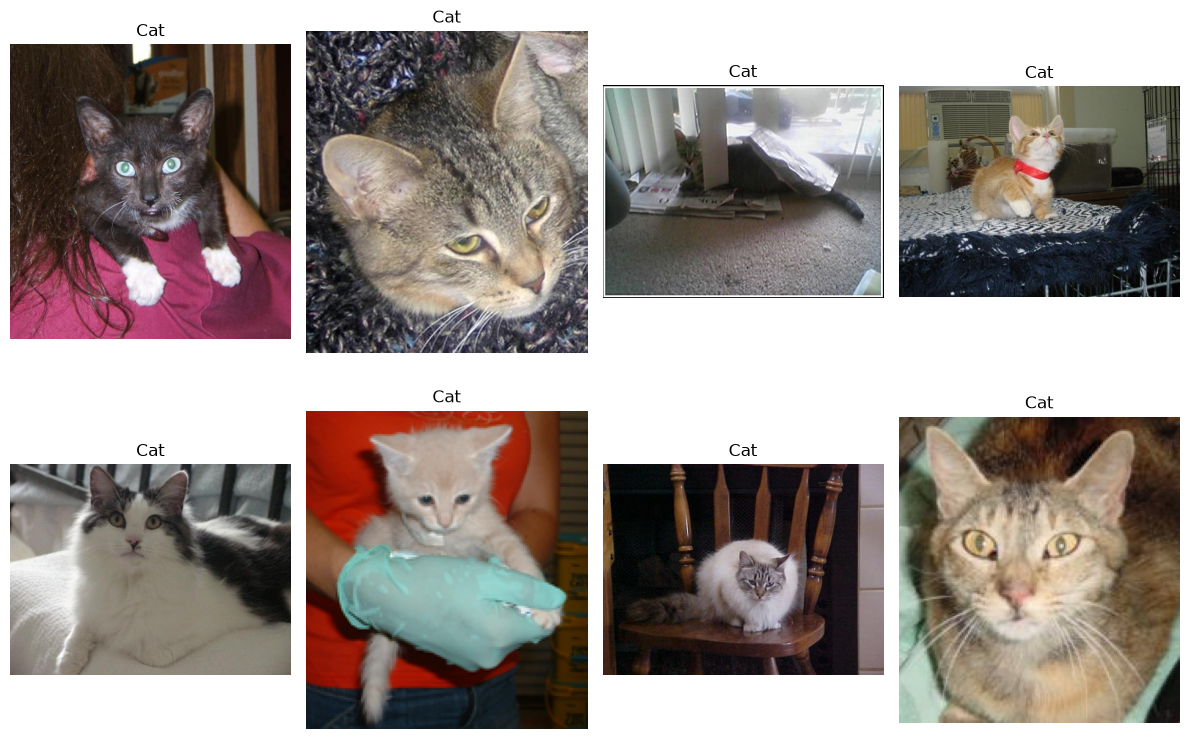

In [6]:
# ==========================================
# DISPLAY CAT IMAGES
# ==========================================

plt.figure(figsize=(12, 8))

for i in range(8):

    image_path = random.choice(cat_images)

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title("Cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

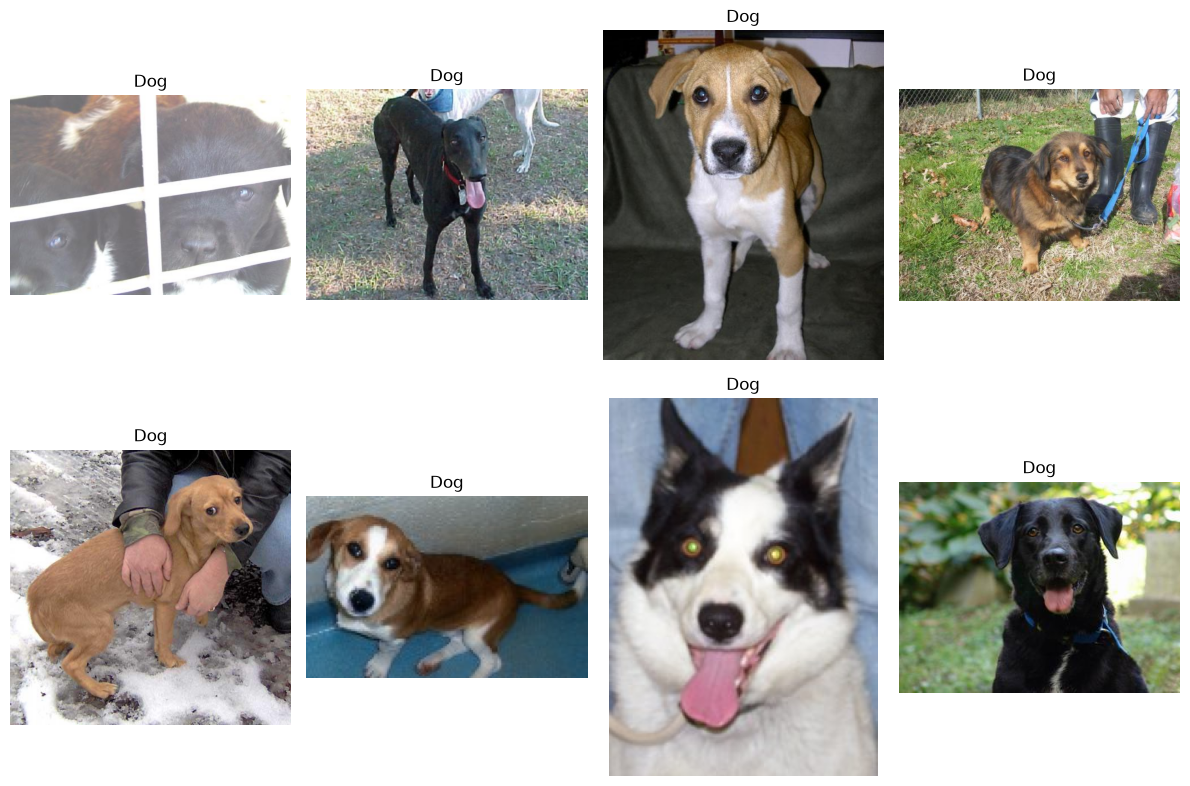

In [7]:
# ==========================================
# DISPLAY DOG IMAGES
# ==========================================

plt.figure(figsize=(12, 8))

for i in range(8):

    image_path = random.choice(dog_images)

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title("Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 🛠️ Image Validation

Real-world image datasets can contain:

- Corrupted images
- Invalid image files
- Empty files
- Unsupported image formats

Training on corrupted images can cause errors during training.

Therefore, we will validate the images before creating our train,
validation, and test datasets.

In [8]:
# ==========================================
# CHECK CORRUPTED IMAGES
# ==========================================

def find_corrupted_images(directory):

    corrupted_images = []

    for image_path in Path(directory).rglob("*"):

        if image_path.is_file():

            try:

                with Image.open(image_path) as image:
                    image.verify()

            except Exception:
                corrupted_images.append(image_path)

    return corrupted_images

In [9]:
# ==========================================
# VALIDATE DATASET
# ==========================================

bad_cat_images = find_corrupted_images(CAT_DIR)
bad_dog_images = find_corrupted_images(DOG_DIR)

print("Corrupted Cat Images:", len(bad_cat_images))
print("Corrupted Dog Images:", len(bad_dog_images))

f:\Anas\DATA_SCIENCE_POTPOLIO\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted Cat Images: 0
Corrupted Dog Images: 0


# ✂️ Train / Validation / Test Split

We will divide the dataset into three parts:

### Training Dataset — 70%

Used to train the CNN.

### Validation Dataset — 15%

Used during training to monitor how well the model performs on unseen images.

### Test Dataset — 15%

Used only at the end to evaluate the final model.

### Important

The test dataset must remain completely unseen during training.

We will use:

- 70% Training
- 15% Validation
- 15% Testing

In [10]:
# ==========================================
# PROCESSED DATASET DIRECTORIES
# ==========================================

PROCESSED_DIR = Path("data/processed")

TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR = PROCESSED_DIR / "validation"
TEST_DIR = PROCESSED_DIR / "test"

directories = [
    TRAIN_DIR / "Cat",
    TRAIN_DIR / "Dog",
    
    VAL_DIR / "Cat",
    VAL_DIR / "Dog",
    
    TEST_DIR / "Cat",
    TEST_DIR / "Dog"
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Processed dataset directories created.")

Processed dataset directories created.


In [11]:
# ==========================================
# CLEAN PREVIOUS PROCESSED DATA
# ==========================================

if PROCESSED_DIR.exists():

    shutil.rmtree(PROCESSED_DIR)

    print("Previous processed dataset removed.")

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Fresh processed dataset created.")

Previous processed dataset removed.
Fresh processed dataset created.


# ✂️ Create Dataset Splitting Function

We will create a reusable function that:

1. Gets all images
2. Shuffles them
3. Selects 70% for training
4. Selects 15% for validation
5. Selects 15% for testing
6. Copies the images into the appropriate folders

In [12]:
# ==========================================
# DATASET SPLITTING FUNCTION
# ==========================================

def split_images(
    source_dir,
    train_dir,
    val_dir,
    test_dir,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42
):

    images = [
        file for file in Path(source_dir).iterdir()
        if file.is_file()
    ]

    random_generator = random.Random(seed)

    random_generator.shuffle(images)

    total = len(images)

    train_end = int(total * train_ratio)

    val_end = train_end + int(total * val_ratio)

    train_images = images[:train_end]

    val_images = images[train_end:val_end]

    test_images = images[val_end:]

    for image in train_images:
        shutil.copy2(
            image,
            train_dir / image.name
        )

    for image in val_images:
        shutil.copy2(
            image,
            val_dir / image.name
        )

    for image in test_images:
        shutil.copy2(
            image,
            test_dir / image.name
        )

    return (
        len(train_images),
        len(val_images),
        len(test_images)
    )

In [13]:
# ==========================================
# SPLIT CAT DATASET
# ==========================================

cat_split = split_images(
    source_dir=CAT_DIR,
    train_dir=TRAIN_DIR / "Cat",
    val_dir=VAL_DIR / "Cat",
    test_dir=TEST_DIR / "Cat"
)

print("Cat Dataset")
print("Training:", cat_split[0])
print("Validation:", cat_split[1])
print("Testing:", cat_split[2])

Cat Dataset
Training: 8749
Validation: 1874
Testing: 1876
